# Figure 1: MSC Matrices per Frequency Band

This notebook generates visualization of MSC (Magnitude-Squared Coherence) functional connectivity matrices and their corresponding network representations for each frequency band.

**Layout**: For each band, a 4-panel figure showing:
- Top left: MSC matrix (rsPre)
- Top right: Network visualization (rsPre)
- Bottom left: MSC matrix (rsPost)
- Bottom right: Network visualization (rsPost)

This allows visual comparison of FC reorganization between pre and post task resting states.

In [1]:
# Setup
from lrgsglib.config.funcs import move_to_rootf
move_to_rootf(pathname='lrgeegfc')

from lrg_eegfc.notebook import *
path_figs = setup_notebook('figures/presentation_figures')

Current working directory: /home/giulio/Documents/research/neural_networks/lrgeegfc
✓ Notebook setup complete
  Figure output: data/figures/presentation_figures


In [2]:
# Additional imports
import sys
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import numpy as np
from pathlib import Path
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Add notebook directory to path for local imports
notebook_dir = Path("ipynb/06_presentation_figures").resolve()
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

# Local utilities
from presentation_utils import CMAP_MATRIX, get_cluster_colors

## Configuration

Change these parameters to run for different patients or phases.

In [3]:
# ============================================================================
# CONFIGURATION - Change these to run for different patients
# ============================================================================
PATIENT = "Pat_02"  # Patient ID
PHASES = ["rsPre", "rsPost"]  # Phases to compare
BANDS = BRAIN_BANDS_NAMES  # All 6 bands: delta, theta, alpha, beta, low_gamma, high_gamma

# Layout parameters
LAYOUT_K = 0.1  # Spring layout k parameter
LAYOUT_SEED = 42

# Paths
MSC_CACHE = Path("data/msc_cache")
OUTPUT_DIR = path_figs / PATIENT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Patient: {PATIENT}")
print(f"Phases: {PHASES}")
print(f"Bands: {BANDS}")
print(f"Output directory: {OUTPUT_DIR}")

Patient: Pat_02
Phases: ['rsPre', 'rsPost']
Bands: ['delta', 'theta', 'alpha', 'beta', 'low_gamma', 'high_gamma']
Output directory: data/figures/presentation_figures/Pat_02


## Load all MSC matrices

In [4]:
from lrg_eegfc.workflow.msc import load_msc_matrix

# Load all MSC matrices
msc_data = {}
for band in BANDS:
    msc_data[band] = {}
    for phase in PHASES:
        matrix = load_msc_matrix(
            PATIENT, phase, band,
            cache_root=MSC_CACHE,
            sparsify="none",  # Dense MSC
            n_surrogates=0,
            nperseg=1024,
        )
        if matrix is not None:
            msc_data[band][phase] = matrix
            print(f"Loaded {band} {phase}: shape {matrix.shape}, mean={matrix.mean():.4f}")
        else:
            print(f"WARNING: Missing {band} {phase}")

Loaded delta rsPre: shape (117, 117), mean=0.0617
Loaded delta rsPost: shape (117, 117), mean=0.0545
Loaded theta rsPre: shape (117, 117), mean=0.0774
Loaded theta rsPost: shape (117, 117), mean=0.0866
Loaded alpha rsPre: shape (117, 117), mean=0.0694
Loaded alpha rsPost: shape (117, 117), mean=0.0952
Loaded beta rsPre: shape (117, 117), mean=0.0641
Loaded beta rsPost: shape (117, 117), mean=0.0583
Loaded low_gamma rsPre: shape (117, 117), mean=0.0468
Loaded low_gamma rsPost: shape (117, 117), mean=0.0370
Loaded high_gamma rsPre: shape (117, 117), mean=0.1368
Loaded high_gamma rsPost: shape (117, 117), mean=0.1231


## Helper function for plotting

In [5]:
def plot_msc_band_comparison(
    band: str,
    msc_matrices: dict,
    phases: list,
    k: float = 0.1,
    seed: int = 42,
    figsize: tuple = (16, 14),
    cmap: str = "magma",
    max_width: float = 4.0,  # Max edge width at MSC=1
    power: float = 2.0,  # Power law exponent - balanced visibility
) -> plt.Figure:
    """Create 4-panel figure comparing MSC matrix and network across phases.
    
    Edge scaling: width = max_width * weight^power
    Edge color: same colormap as matrix (magma)
    """
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.25, wspace=0.2)
    
    # Get colormap
    cmap_obj = plt.cm.get_cmap(cmap)
    
    # Compute shared layout based on average of both matrices
    avg_matrix = np.mean([msc_matrices[p] for p in phases], axis=0)
    G_avg = nx.from_numpy_array(avg_matrix)
    shared_pos = nx.spring_layout(G_avg, seed=seed, k=k, iterations=100)
    
    for row, phase in enumerate(phases):
        matrix = msc_matrices[phase]
        G = nx.from_numpy_array(matrix)
        
        # =====================================================================
        # Left column: MSC Matrix
        # =====================================================================
        ax_matrix = fig.add_subplot(gs[row, 0])
        
        im = ax_matrix.imshow(
            matrix,
            cmap=cmap,
            vmin=0,
            vmax=1,
            aspect='equal',
            interpolation='none',
        )
        
        # Colorbar
        divider = make_axes_locatable(ax_matrix)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label("MSC", fontsize=11)
        
        # Stats annotation
        triu_idx = np.triu_indices_from(matrix, k=1)
        mean_val = matrix[triu_idx].mean()
        std_val = matrix[triu_idx].std()
        
        ax_matrix.set_title(
            f"{phase} - MSC Matrix\nmean={mean_val:.3f}, std={std_val:.3f}",
            fontsize=12,
            fontweight='bold'
        )
        ax_matrix.set_xlabel("Channel", fontsize=10)
        ax_matrix.set_ylabel("Channel", fontsize=10)
        
        # =====================================================================
        # Right column: Network visualization
        # =====================================================================
        ax_network = fig.add_subplot(gs[row, 1])
        
        # Get edge weights
        edges = list(G.edges(data=True))
        weights = np.array([e[2]['weight'] for e in edges])
        
        # Power law scaling for width
        scaled = np.power(weights, power)
        widths = max_width * scaled
        
        # Color edges using same colormap as matrix
        # Alpha also uses power law for visibility
        alphas = np.power(weights, power)
        edge_colors = [(*cmap_obj(w)[:3], a) for w, a in zip(weights, alphas)]
        
        # Simple uniform node coloring
        node_color = 'steelblue'
        
        # Draw network
        nx.draw_networkx_nodes(
            G, shared_pos, ax=ax_network,
            node_size=80,
            node_color=node_color,
            alpha=0.9,
            edgecolors='white',
            linewidths=0.5,
        )
        
        # Draw edges with colormap coloring
        nx.draw_networkx_edges(
            G, shared_pos, ax=ax_network,
            width=widths,
            edge_color=edge_colors,
        )
        
        # Stats for network
        n_nodes = G.number_of_nodes()
        n_edges = G.number_of_edges()
        
        ax_network.set_title(
            f"{phase} - Network\n{n_nodes} nodes, {n_edges} edges",
            fontsize=12,
            fontweight='bold'
        )
        ax_network.axis('off')
    
    # Overall title
    fig.suptitle(
        f"{PATIENT} - {band.upper()} Band MSC\nPre vs Post Task Comparison",
        fontsize=16,
        fontweight='bold',
        y=0.98
    )
    
    return fig

## Generate figures for all bands

Generating figures with k=0.1


/tmp/ipykernel_457774/3665767063.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


Saved: data/figures/presentation_figures/Pat_02/fig1_msc_delta.pdf


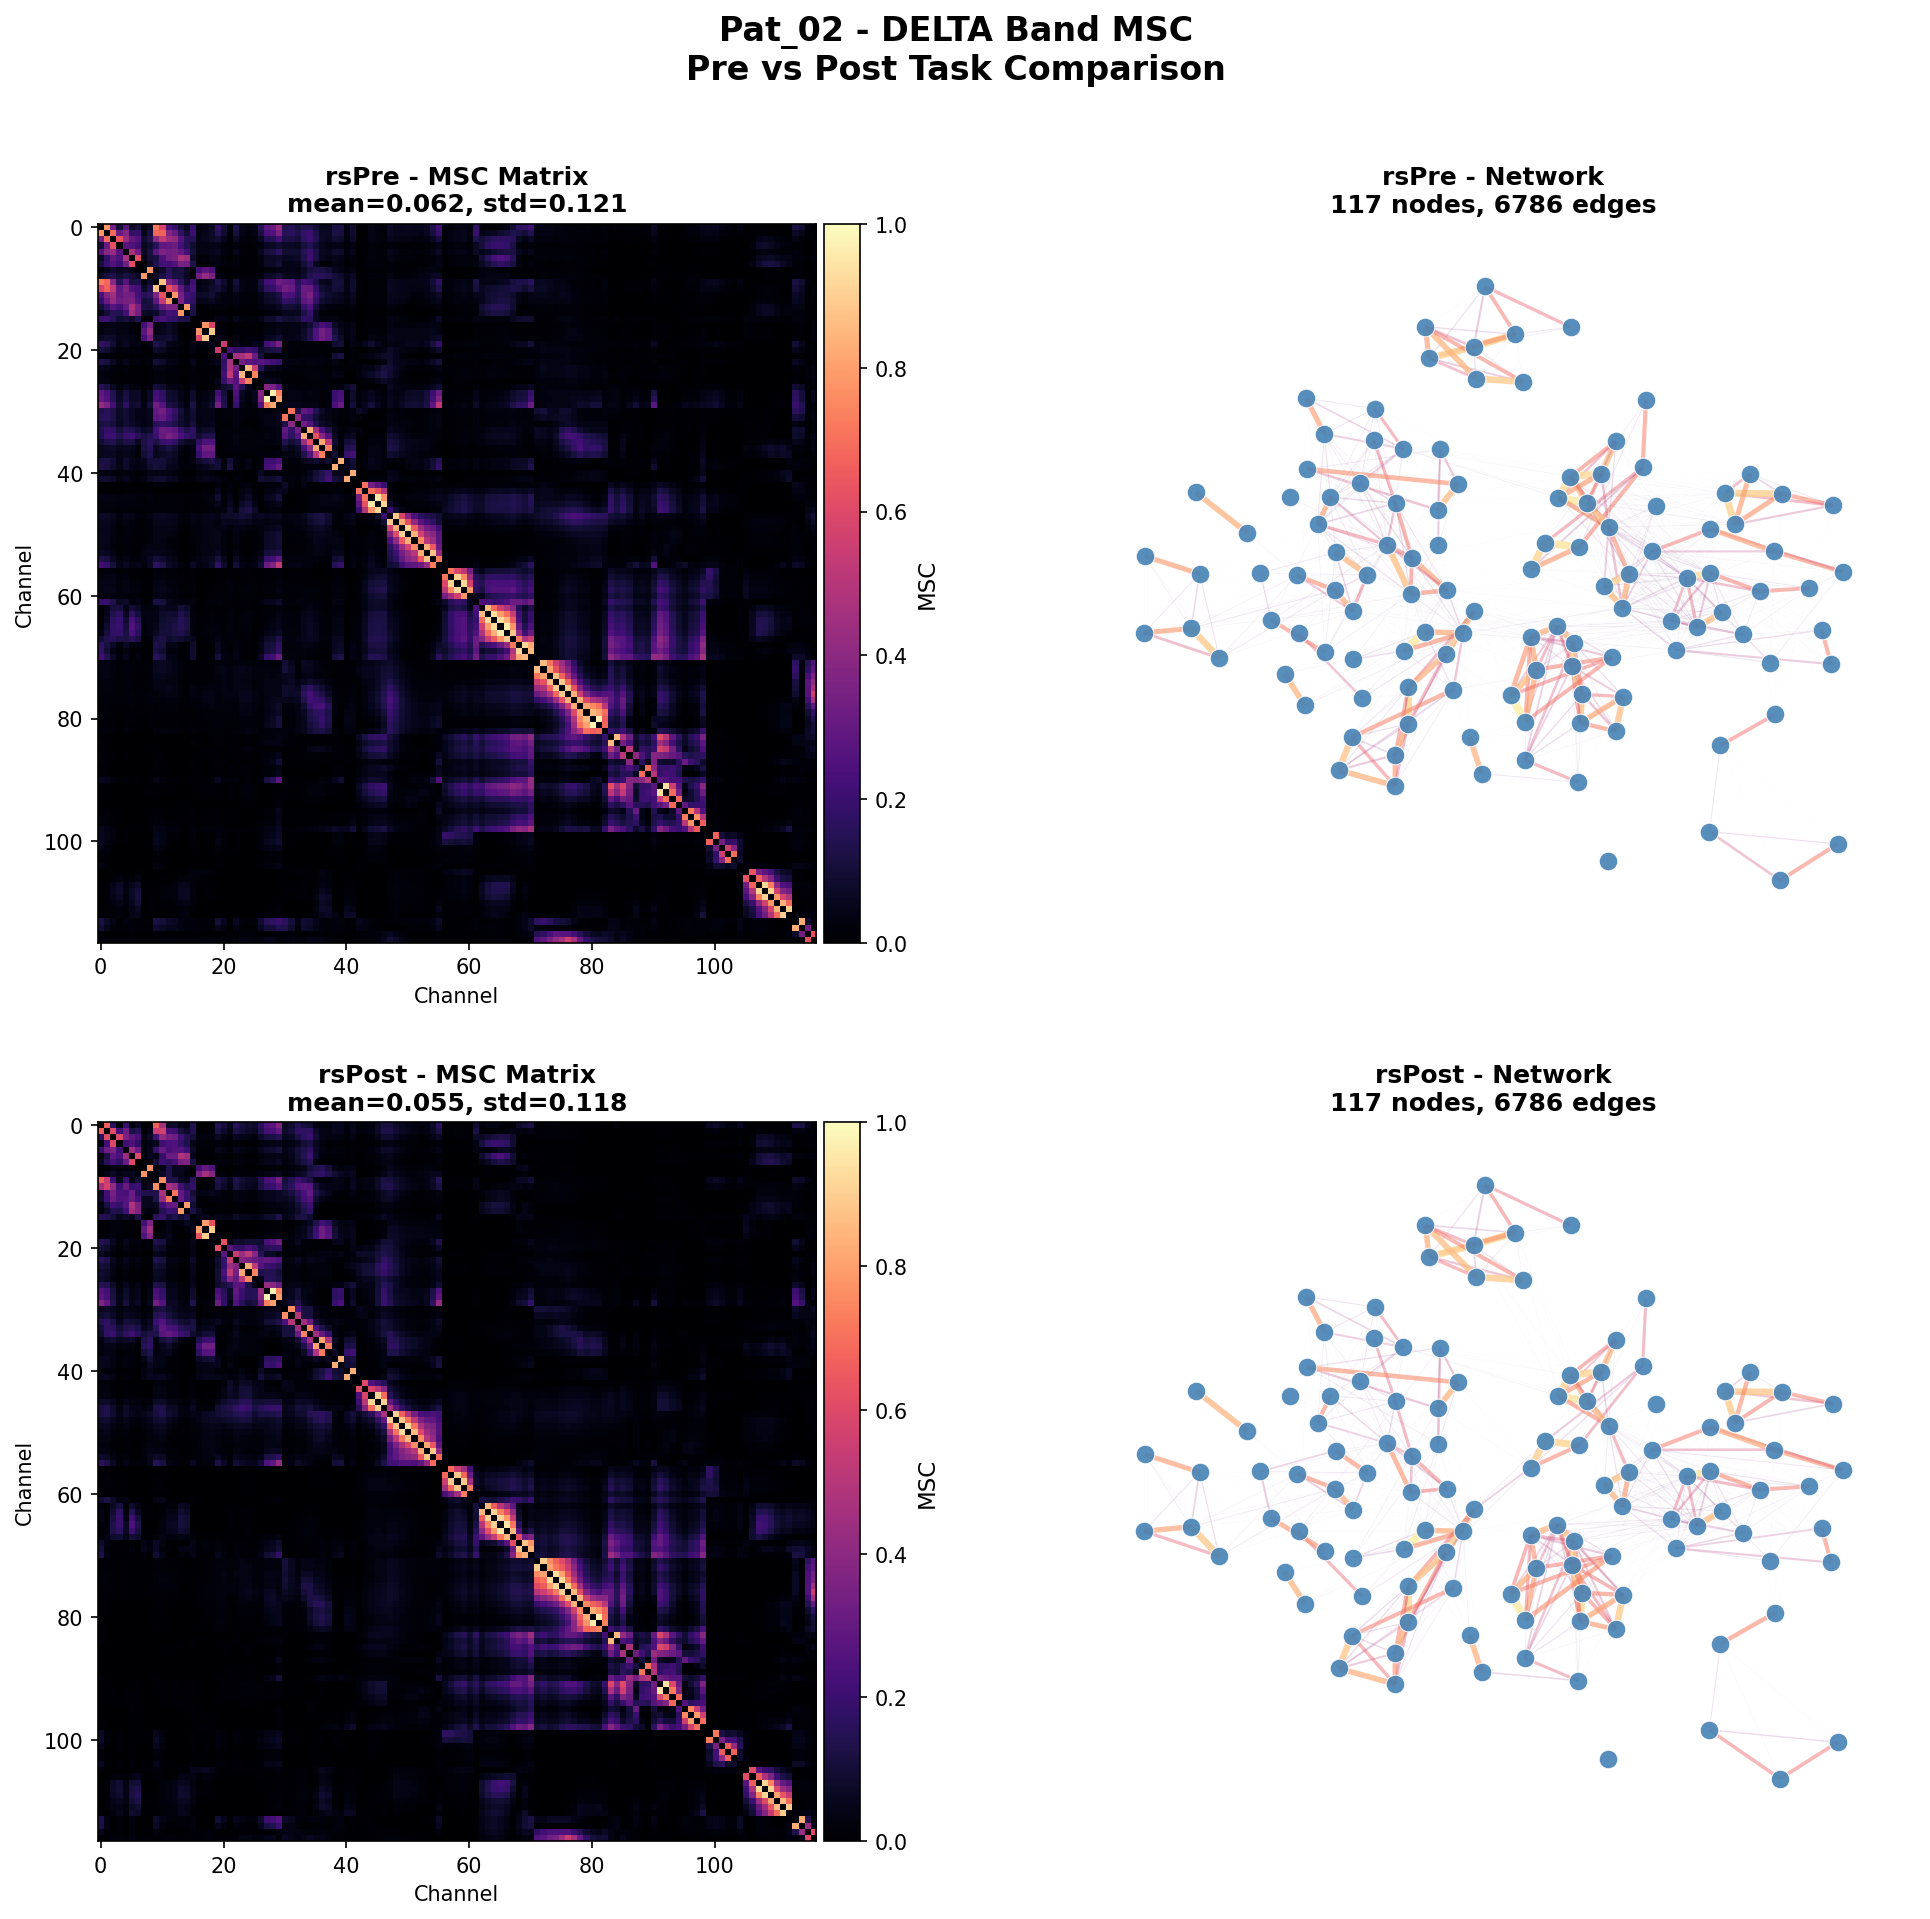

/tmp/ipykernel_457774/3665767063.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


Saved: data/figures/presentation_figures/Pat_02/fig1_msc_theta.pdf


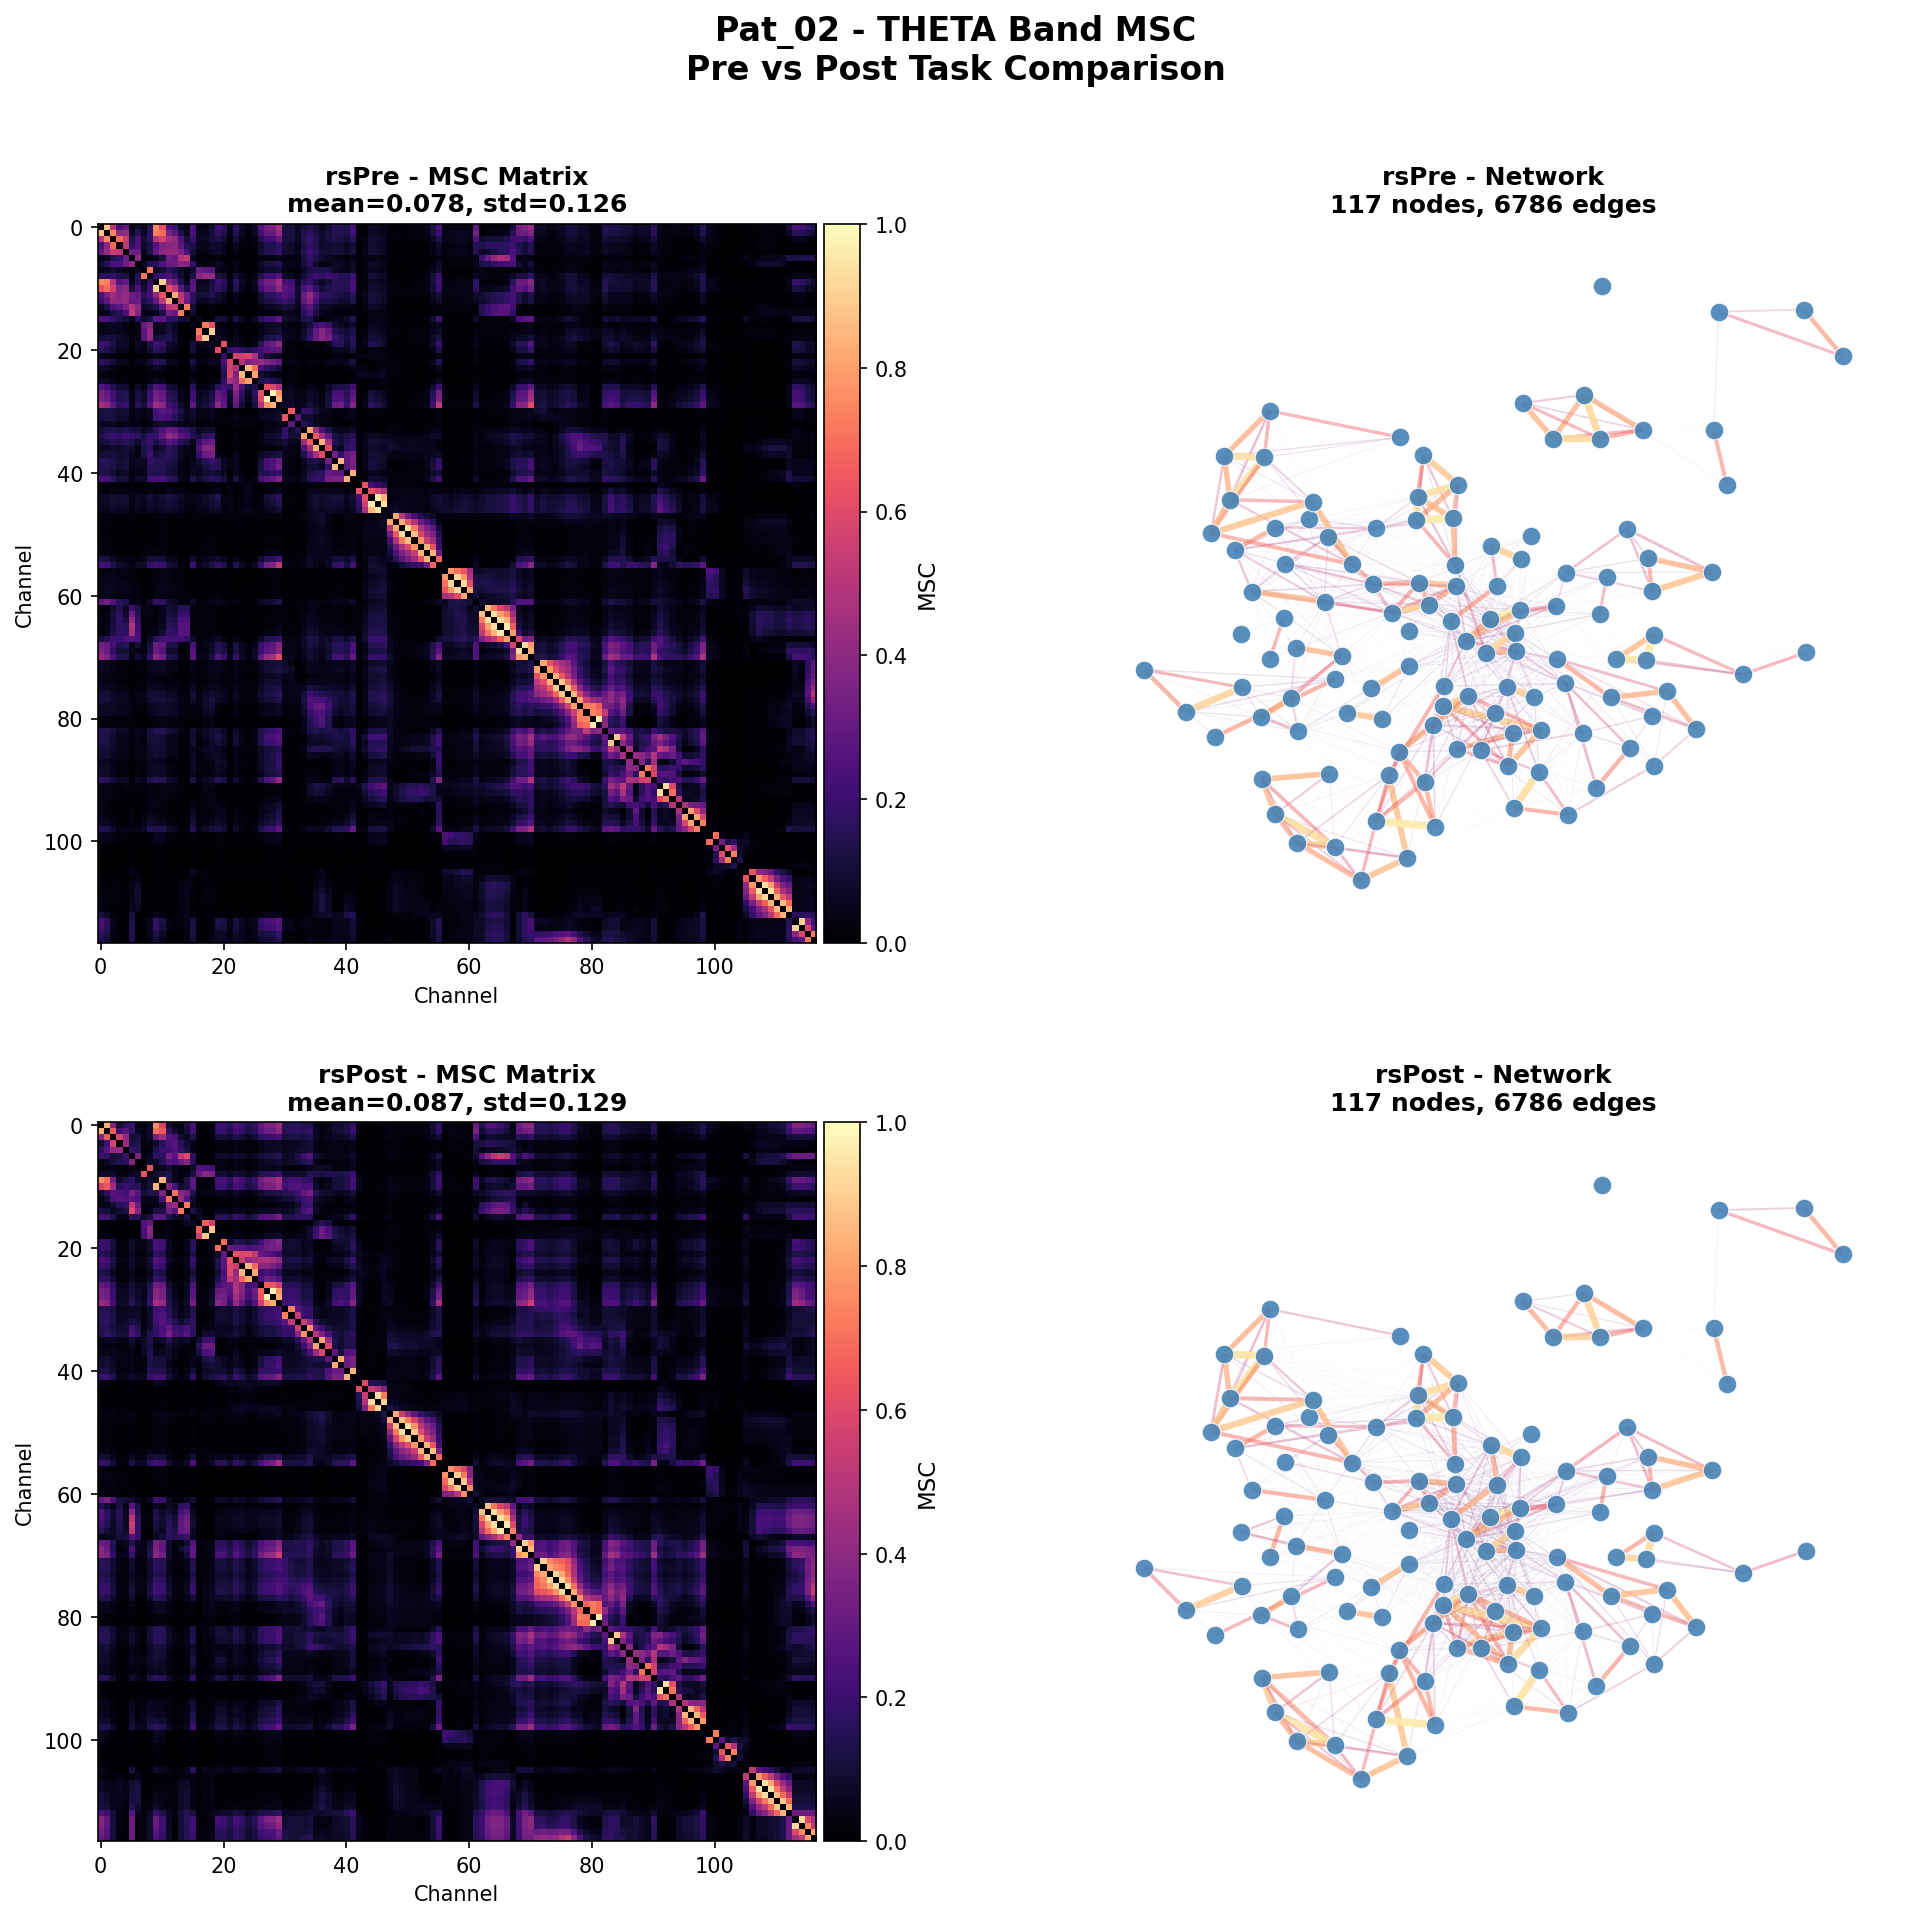

/tmp/ipykernel_457774/3665767063.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


Saved: data/figures/presentation_figures/Pat_02/fig1_msc_alpha.pdf


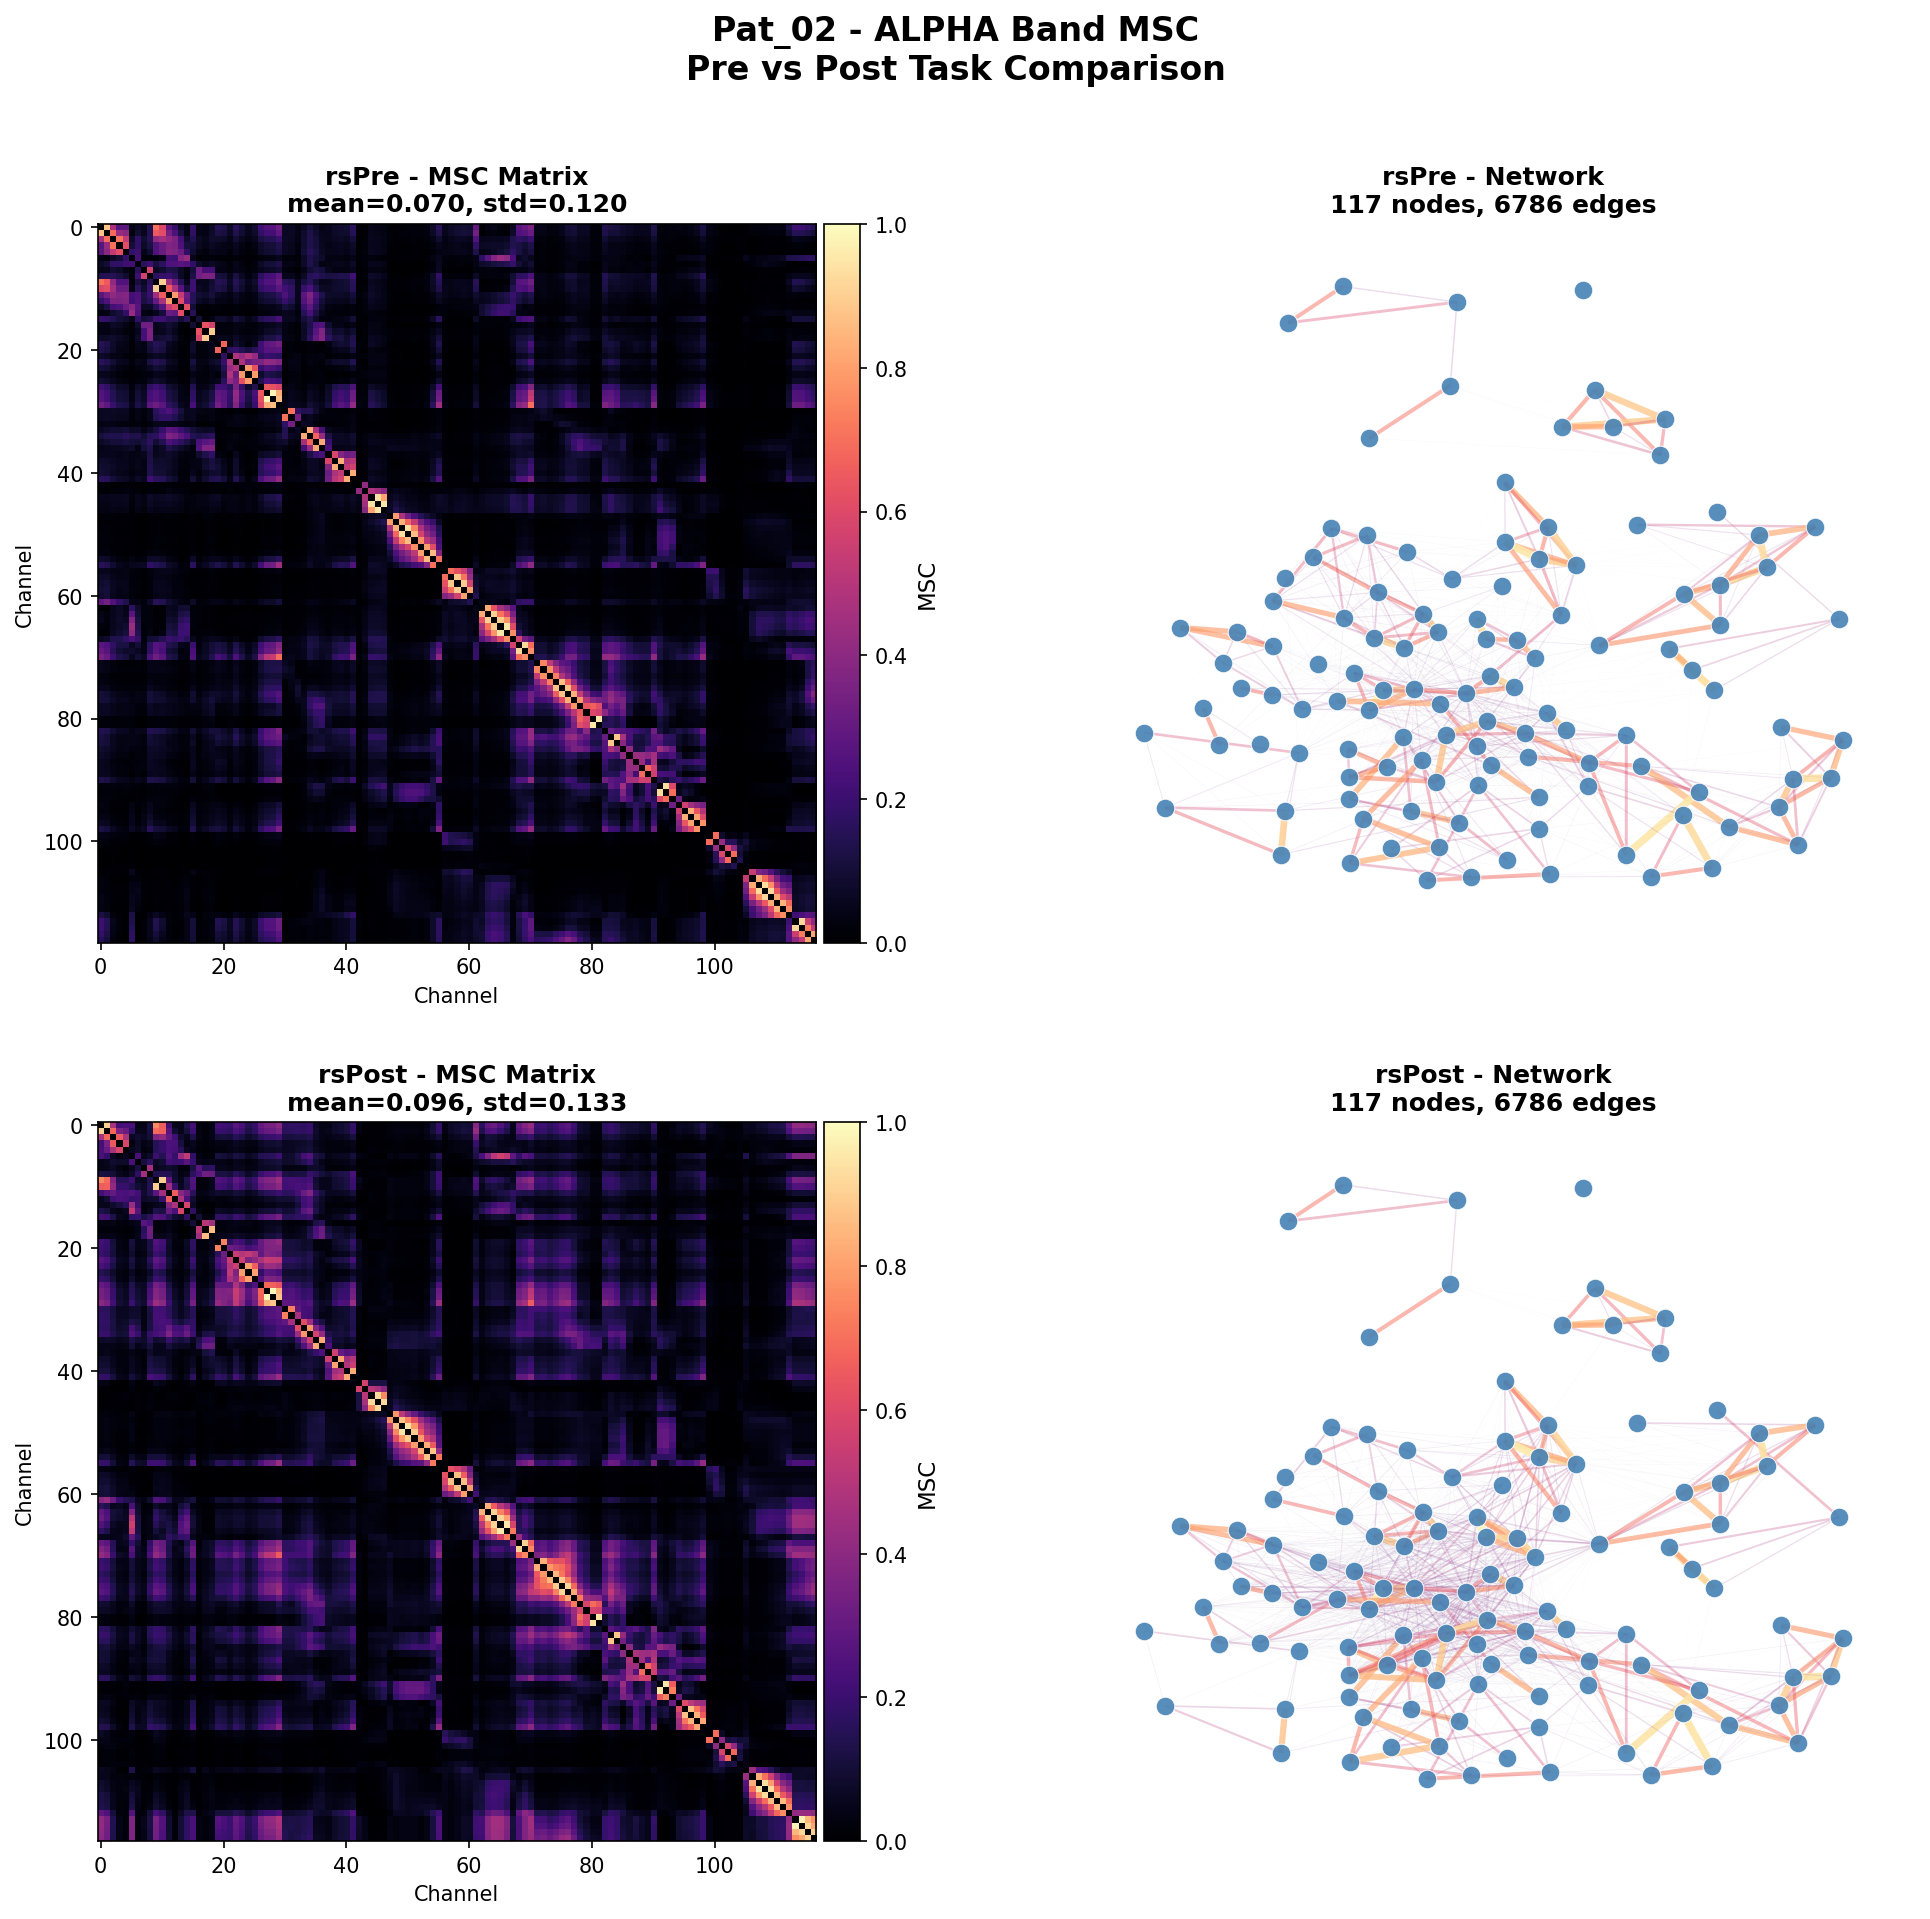

/tmp/ipykernel_457774/3665767063.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


Saved: data/figures/presentation_figures/Pat_02/fig1_msc_beta.pdf


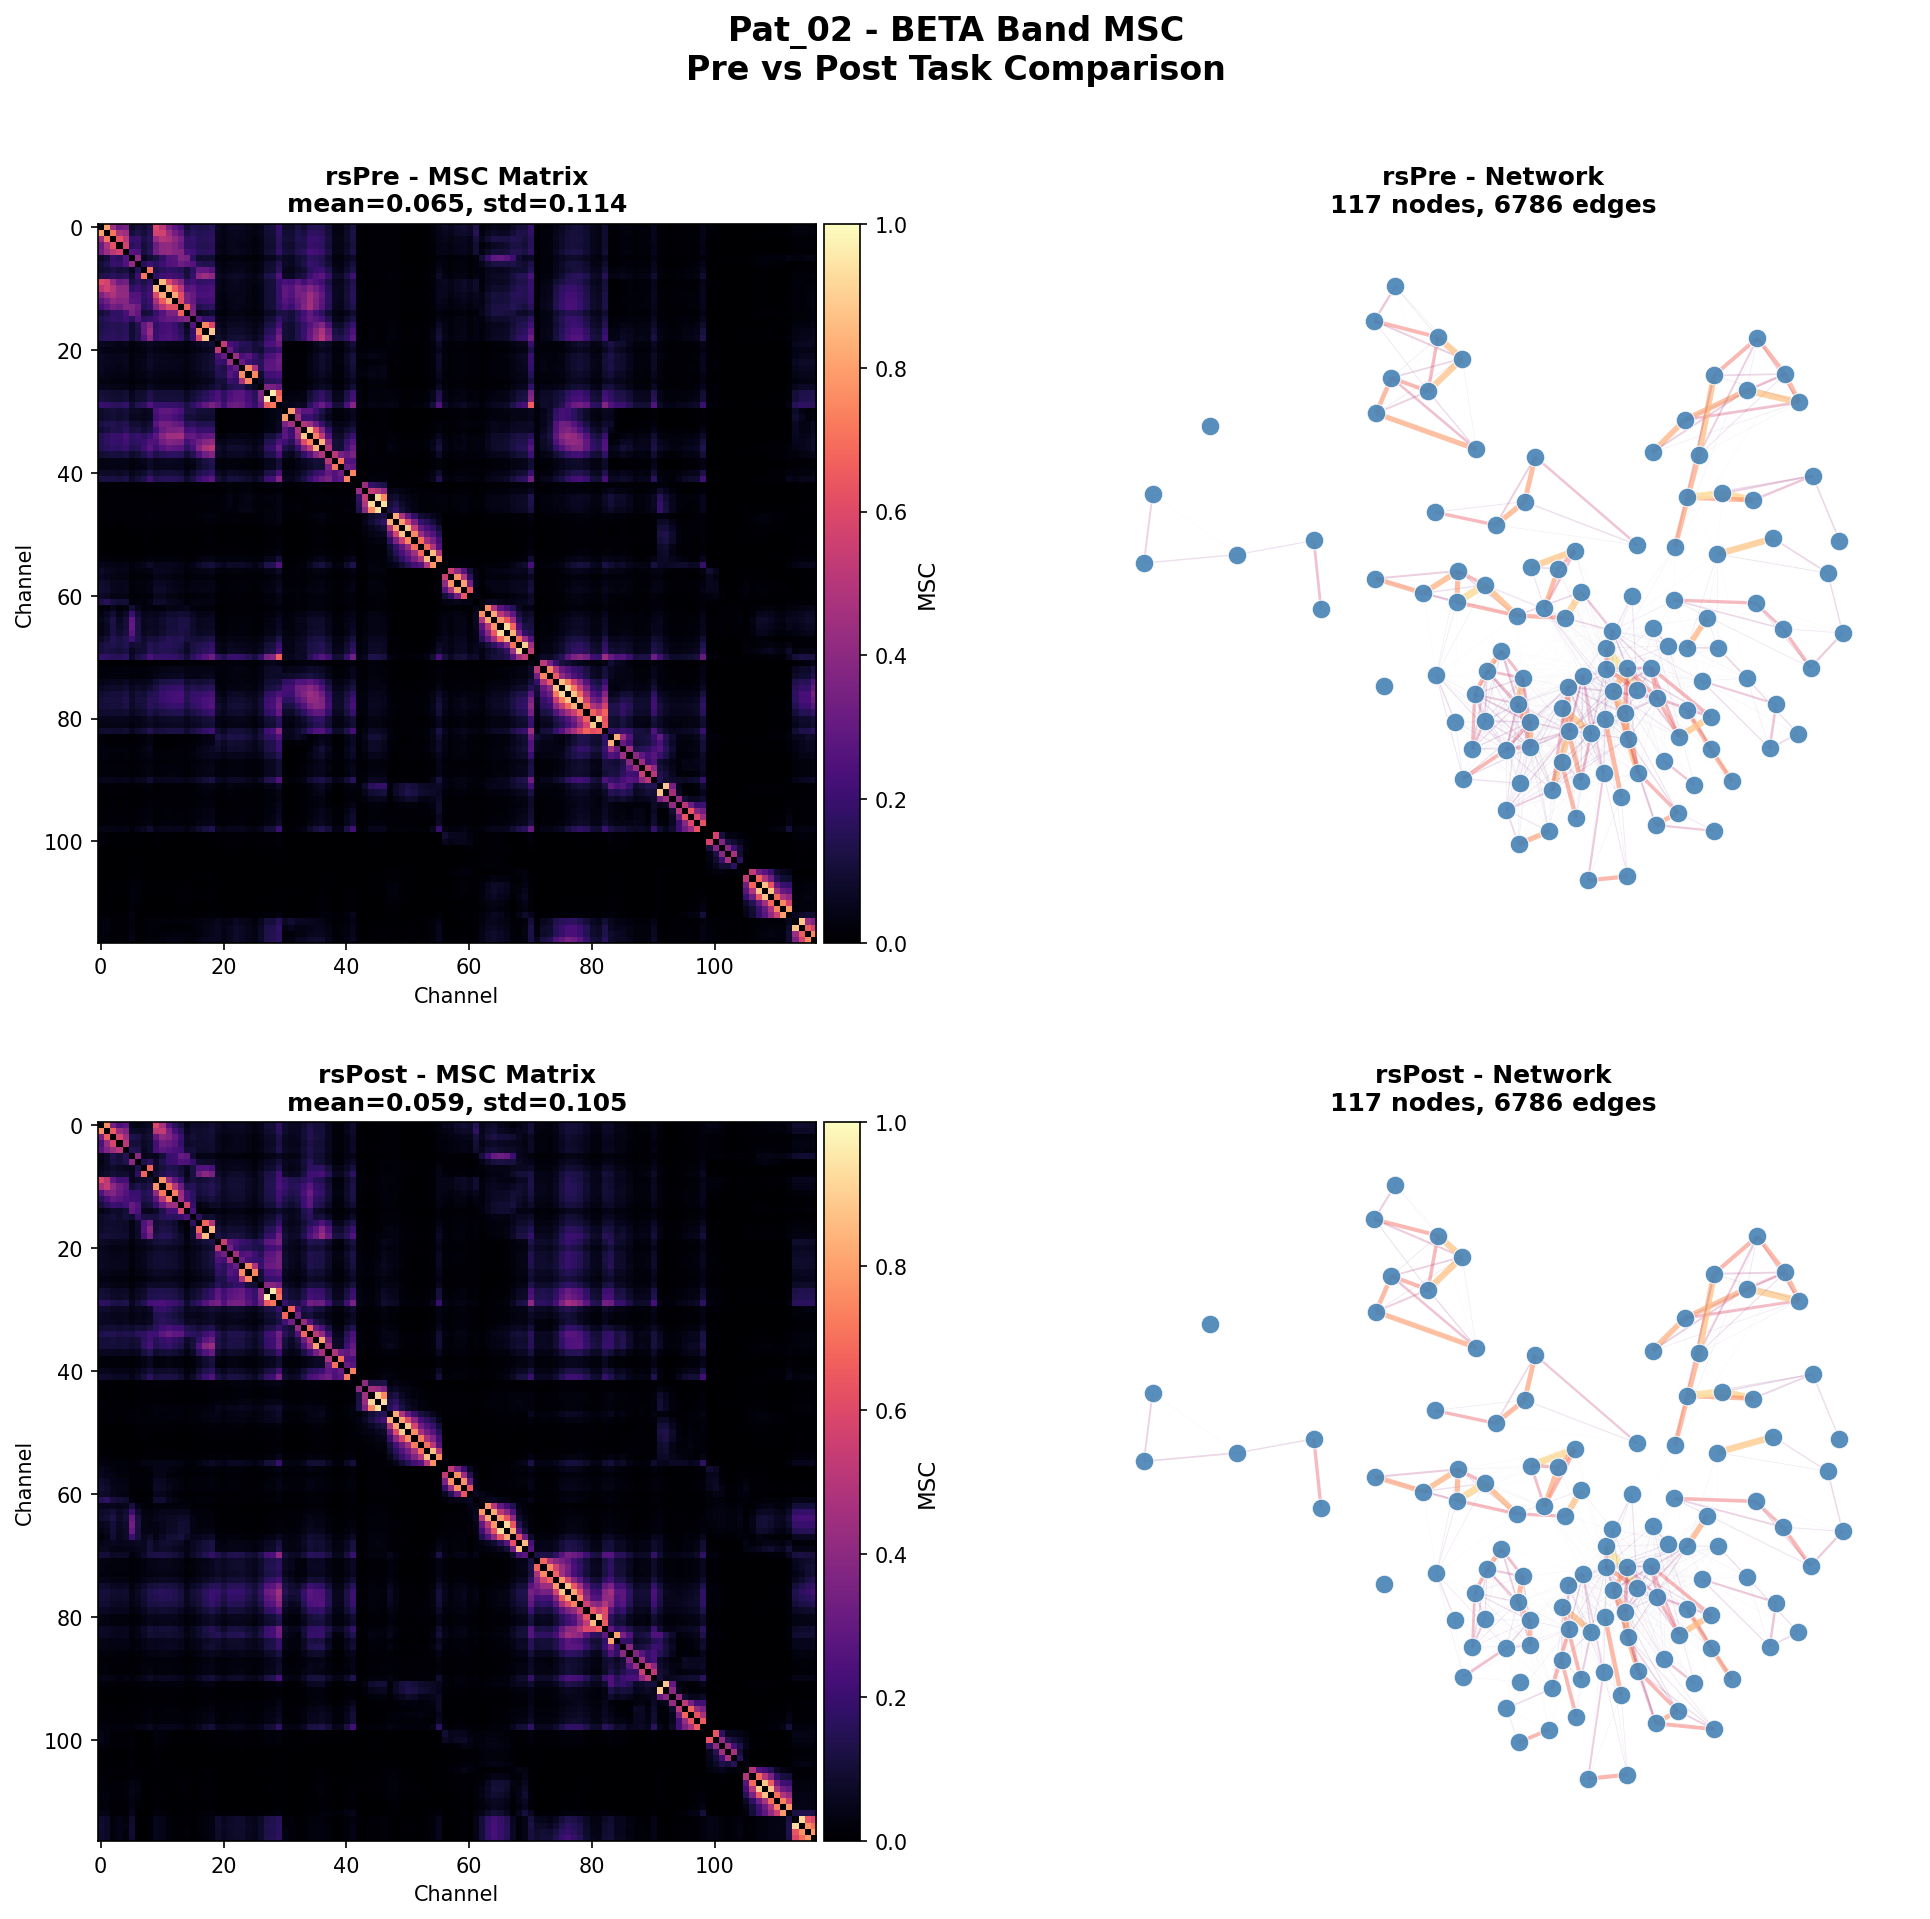

/tmp/ipykernel_457774/3665767063.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


Saved: data/figures/presentation_figures/Pat_02/fig1_msc_low_gamma.pdf


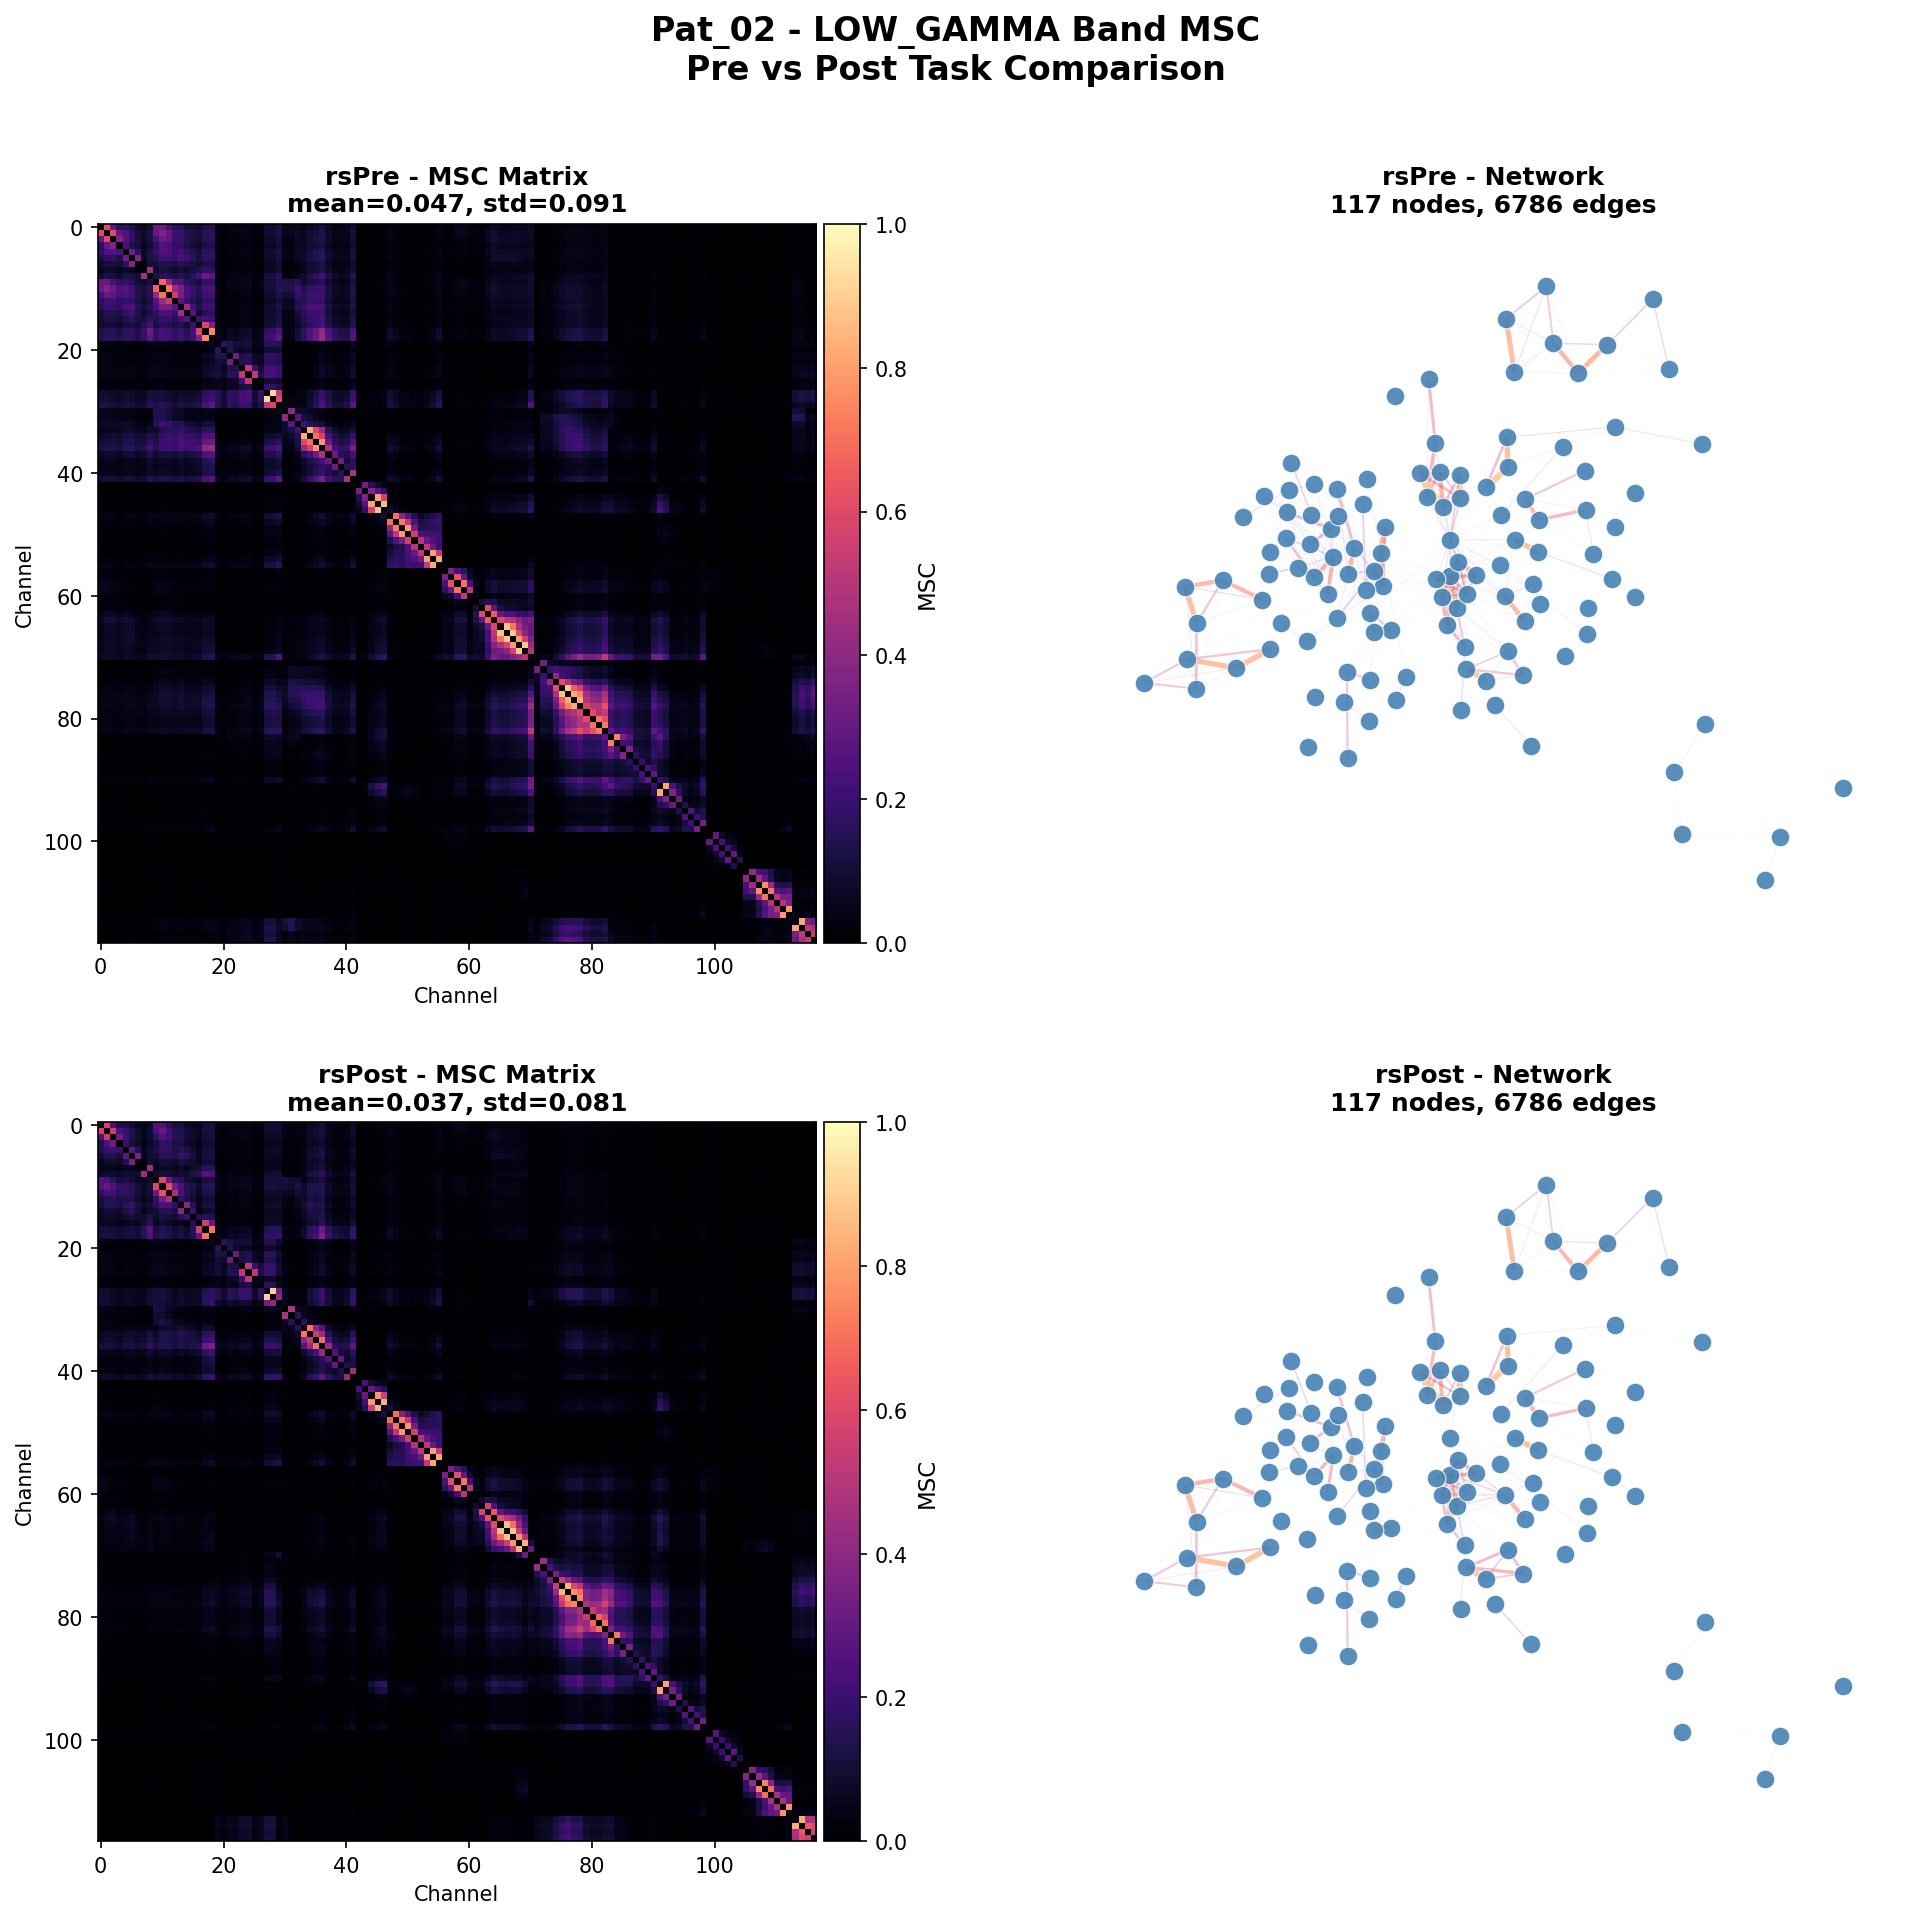

/tmp/ipykernel_457774/3665767063.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_obj = plt.cm.get_cmap(cmap)


Saved: data/figures/presentation_figures/Pat_02/fig1_msc_high_gamma.pdf


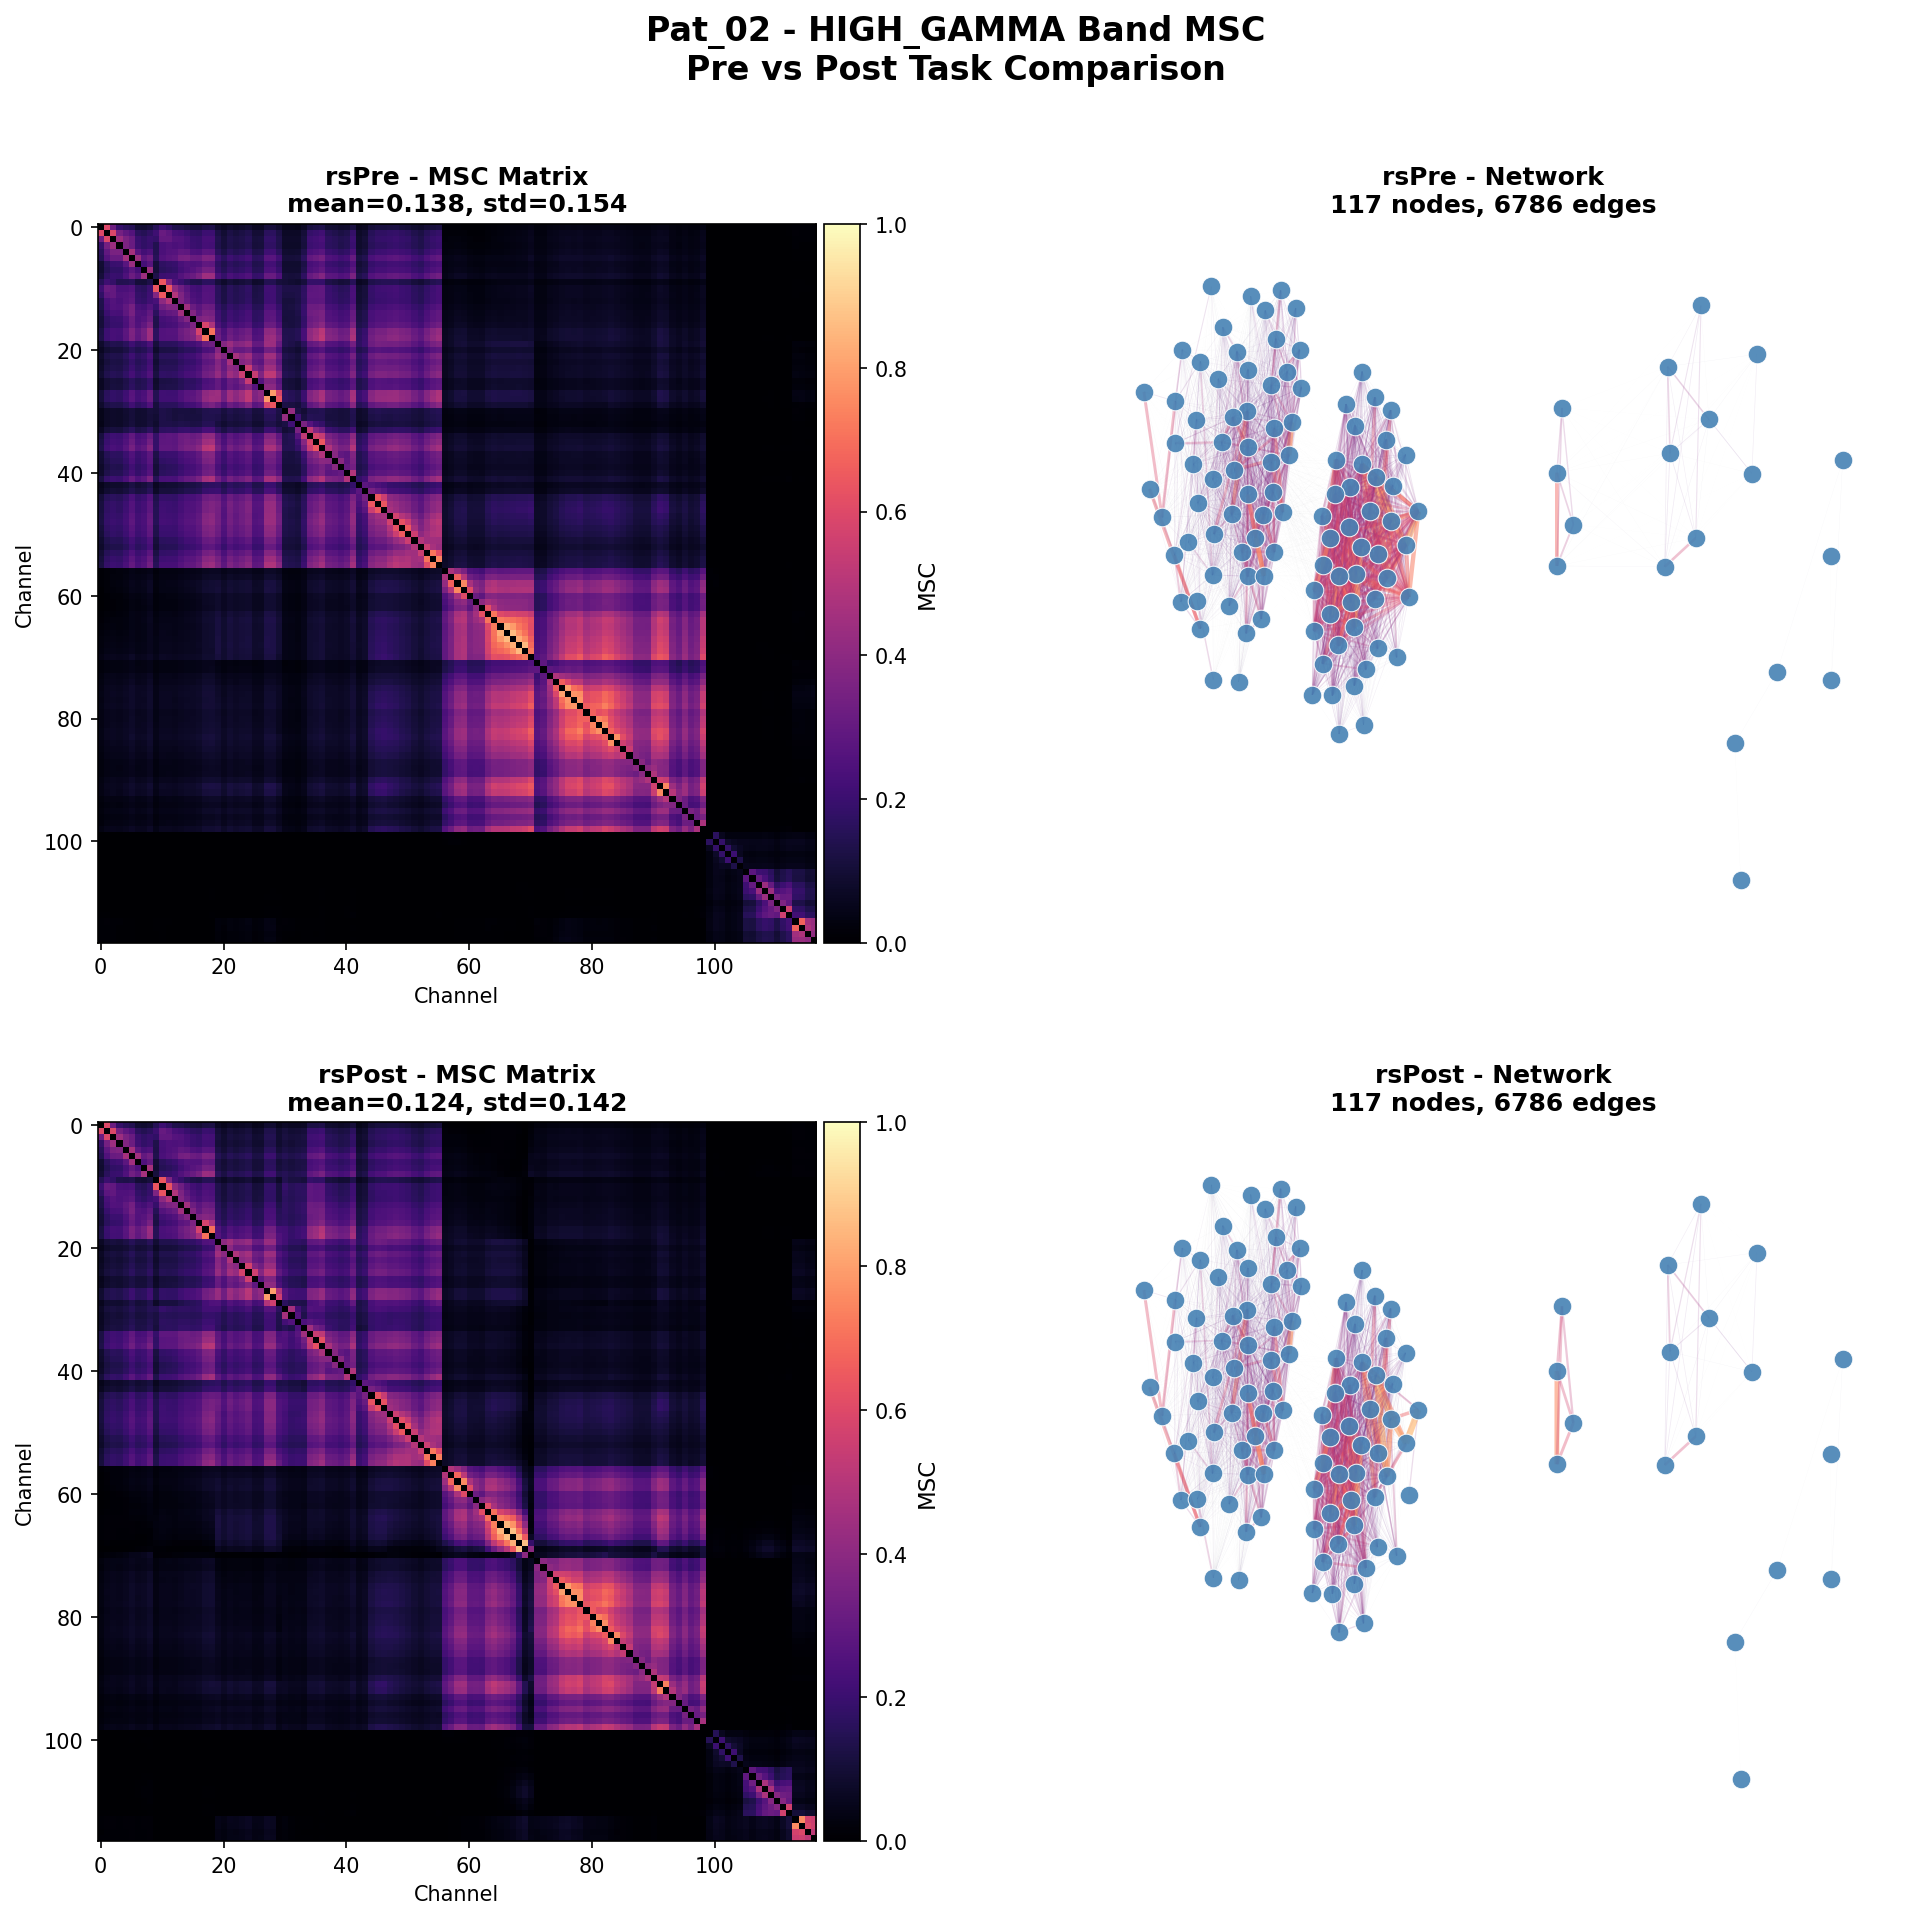


Done! All Figure 1 panels saved.


In [6]:
print(f"Generating figures with k={LAYOUT_K}")
print("="*60)

for band in BANDS:
    if band not in msc_data or not all(p in msc_data[band] for p in PHASES):
        print(f"Skipping {band} - missing data")
        continue
    
    fig = plot_msc_band_comparison(
        band,
        msc_data[band],
        PHASES,
        k=LAYOUT_K,
        seed=LAYOUT_SEED,
    )
    
    output_path = OUTPUT_DIR / f"fig1_msc_{band}.pdf"
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"Saved: {output_path}")
    plt.show()
    plt.close(fig)

print("\nDone! All Figure 1 panels saved.")

## Summary statistics

In [7]:
# Print summary statistics for all bands/phases
print("\nMSC Summary Statistics")
print("="*70)
print(f"{'Band':<12} {'Phase':<12} {'Mean':>10} {'Std':>10} {'Max':>10}")
print("-"*70)

for band in BANDS:
    for phase in PHASES:
        if band in msc_data and phase in msc_data[band]:
            matrix = msc_data[band][phase]
            triu = matrix[np.triu_indices_from(matrix, k=1)]
            print(f"{band:<12} {phase:<12} {triu.mean():>10.4f} {triu.std():>10.4f} {triu.max():>10.4f}")
    print()


MSC Summary Statistics
Band         Phase              Mean        Std        Max
----------------------------------------------------------------------
delta        rsPre            0.0622     0.1213     0.9733
delta        rsPost           0.0550     0.1182     0.9733

theta        rsPre            0.0781     0.1257     0.9783
theta        rsPost           0.0874     0.1290     0.9794

alpha        rsPre            0.0700     0.1200     0.9823
alpha        rsPost           0.0960     0.1327     0.9846

beta         rsPre            0.0647     0.1142     0.9634
beta         rsPost           0.0588     0.1055     0.9638

low_gamma    rsPre            0.0473     0.0907     0.9156
low_gamma    rsPost           0.0373     0.0810     0.9012

high_gamma   rsPre            0.1380     0.1543     0.8577
high_gamma   rsPost           0.1242     0.1422     0.8699

